In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tabpfn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#loading dataset
import pandas as pd
df = pd.read_csv('data.csv')
df.head()

In [ ]:
#checking details
print(df.info())
df.isnull().sum()

In [ ]:
#extracting relevant data
import numpy as np

df_daily = df[['Calendar Day', 'State', 'District', 'Daily actual', 'Daily normal', 'Percentage of daily departure']].copy()
df_daily = df_daily.dropna(subset=['Daily actual', 'Daily normal'])
df_daily['Calendar Day'] = pd.to_datetime(df_daily['Calendar Day'], errors='coerce')
df_daily['Month'] = df_daily['Calendar Day'].dt.month
df_daily['Year'] = df_daily['Calendar Day'].dt.year


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

In [11]:
#downloading TABpfn
!pip install tabpfn
from tabpfn import TabPFNRegressor

In [19]:
#selecting relevant columns
df_daily['simulated_forecast'] = df_daily['Daily normal']
df_daily['forecast_error'] = df_daily['Daily actual'] - df_daily['simulated_forecast']

In [21]:
#converting date and extract features
df_daily['Calendar Day'] = pd.to_datetime(df_daily['Calendar Day'], errors='coerce')
df_daily = df_daily.dropna(subset=['Calendar Day'])
df_daily['Month'] = df_daily['Calendar Day'].dt.month
df_daily['Year'] = df_daily['Calendar Day'].dt.year

In [23]:
#simulating forecast and error
df_daily['simulated_forecast'] = df_daily['Daily normal']
df_daily['forecast_error'] = df_daily['Daily actual'] - df_daily['simulated_forecast']

In [25]:
#encoding categorical variables
le_state = LabelEncoder()
le_district = LabelEncoder()
df_daily['State_enc'] = le_state.fit_transform(df_daily['State'])
df_daily['District_enc'] = le_district.fit_transform(df_daily['District'])

In [27]:
#preparing features and target
features = ['simulated_forecast', 'Month', 'Year', 'State_enc', 'District_enc']
X = df_daily[features]
y = df_daily['forecast_error']

In [29]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
#reduce the size of data
X_train_small = X_train.sample(n=1000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [47]:
#train TabPFN
regressor = TabPFNRegressor(device="cpu")
regressor.fit(X_train_small.to_numpy(), y_train_small.to_numpy())

C:\Users\aarus\anaconda3\Lib\site-packages\tabpfn\regressor.py:459: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(self.device, X)


TabPFNRegressor(device='cpu')

In [51]:
#predicting on a small test subset
X_test_small = X_test.sample(n=500, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

In [53]:
#predictions
preds = regressor.predict(X_test_small.to_numpy())

In [54]:
#evaluation
mae = mean_absolute_error(y_test_small, preds)
print(f"MAE of forecast error correction (1000 sample train, 500 test): {mae:.2f} mm")

MAE of forecast error correction (1000 sample train, 500 test): 3.69 mm


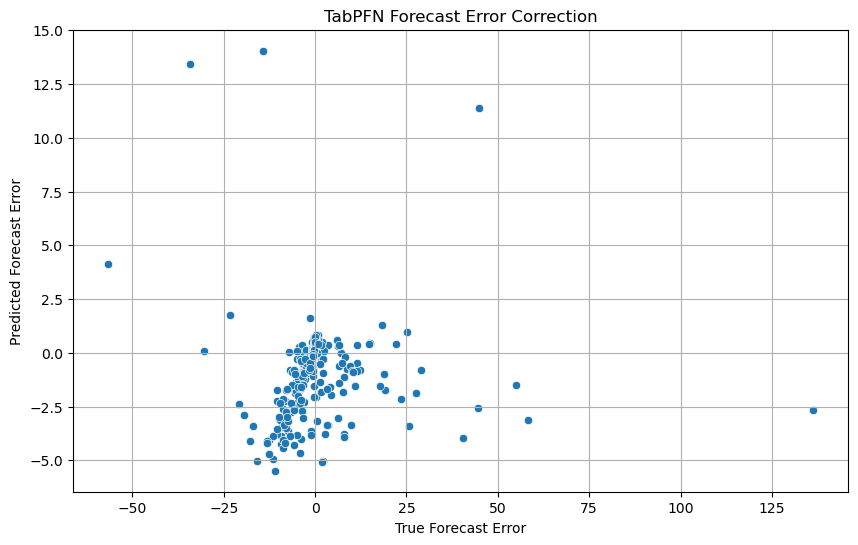

In [55]:
#visualizing predictions
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_small, y=preds)
plt.xlabel("True Forecast Error")
plt.ylabel("Predicted Forecast Error")
plt.title("TabPFN Forecast Error Correction")
plt.grid(True)
plt.show()

In [59]:
#adjusting simulated forecast
adjusted_forecast = X_test_small['simulated_forecast'] + preds
actual = X_test_small.copy()
actual['adjusted_forecast'] = adjusted_forecast
actual['true_actual'] = y_test_small + X_test_small['simulated_forecast']

In [61]:
#evaluating adjusted forecast
adjusted_mae = mean_absolute_error(actual['true_actual'], actual['adjusted_forecast'])
print(f"MAE of adjusted forecast: {adjusted_mae:.2f} mm")

MAE of adjusted forecast: 3.69 mm
